# Salary Predictions
DTSC 2301 · Portfolio Project Two · Anirudh Ramesh



## 1. Problem Definition
Prediction problem: Predicts Employee's salary in companies and their mean/median

Target Variable: Employee Salary

Classification or Regression: Regression

Who might benefit from this model or its predictions?: Job seekers seeking for jobs with estimated salary, and current employees can benefit with salary hike, and look for other companies with better salaries.

Why is this problem meaningful or worth investigating?: Helps employees look for companies with their salary expectations

## 2. Background and Context

I have to describe the importance of salary predictions, and why machine learning is significant to this model. Explain why this is signifies as a regression model, rather than classification model type. My goal is to learning machine learning models, and published github for developing the portfolio 

### References
Salary Prediction Data. (n.d.). Www.Kaggle.Com. Retrieved October 4, 2026, from https://www.kaggle.com/datasets/mrsimple07/salary-prediction-data/data


## 1. Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
os.makedirs("images", exist_ok=True)

## 2. Data Description
 - **Source:** https://www.kaggle.com/datasets/mrsimple07/salary-prediction-data
 - **Dataset:** The "Salary Prediction Dataset" is a synthetic dataset generated for the purpose of exploring salary prediction tasks. It contains simulated data reflecting various factors influencing salary levels such as education, experience, location, job title, age, and gender
 - **Features/Columns:** Age, Gender, Education level, Job Title, Years of Experience, Location
 - **Unit:** Rows represent each employee record
 - **Size:** 1000 rows, 7 columns
 - **Missing Values:** 0


I imported kagglehub using API. I loaded CSV file directly into a Pandas Dataframe

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


df_salarydata = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mrsimple07/salary-prediction-data",
    "salary_prediction_data.csv",  
)


print(df_salarydata.head())

     Education  Experience  Location Job_Title  Age  Gender         Salary
0  High School           8     Urban   Manager   63    Male   84620.053665
1          PhD          11  Suburban  Director   59    Male  142591.255894
2     Bachelor          28  Suburban   Manager   61  Female   97800.255404
3  High School          29     Rural  Director   45    Male   96834.671282
4          PhD          25     Urban   Analyst   26  Female  132157.786175


Setting salary as target variable 
validate missing and duplicate

In [5]:

TARGET = "Salary"
print(df_salarydata.shape)
print("Missing values:", int(df_salarydata.isna().sum().sum()), "| Duplicates:", int(df_salarydata.duplicated().sum()))
df_salarydata.head()

(1000, 7)
Missing values: 0 | Duplicates: 0


,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


## 4. Data Understanding and Exploration

In [9]:
display(df_salarydata.describe(include="all").T)

mean_s, median_s, skew = df_salarydata[TARGET].mean(), df_salarydata[TARGET].median(), df_salarydata[TARGET].skew()
print(f"Mean: ${mean_s:,.0f} | Median: ${median_s:,.0f} | Skew: {skew:.2f}")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Education,1000,4,High School,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,1000.0,NaN,NaN,NaN,14.771,8.341111,1.0,7.0,15.0,22.0,29.0
Location,1000,3,Suburban,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,1000,4,Director,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,42.377,13.609412,20.0,30.0,43.0,55.0,64.0
Gender,1000,2,Male,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1000.0,NaN,NaN,NaN,105558.404239,28256.972075,33510.510669,85032.141517,104314.518315,126804.047524,193016.60215


Mean: $105,558 | Median: $104,315 | Skew: 0.10


In [14]:
display(df_salarydata.describe(include="all").T)

mean_age, median_age, skew_age = df_salarydata["Age"].mean(), df_salarydata["Age"].median(), df_salarydata["Age"].skew()
print(f"Mean: {mean_age:,.0f} | Median: {median_age:,.0f} | Skew: {skew_age:.2f}")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Education,1000,4,High School,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,1000.0,NaN,NaN,NaN,14.771,8.341111,1.0,7.0,15.0,22.0,29.0
Location,1000,3,Suburban,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,1000,4,Director,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,42.377,13.609412,20.0,30.0,43.0,55.0,64.0
Gender,1000,2,Male,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1000.0,NaN,NaN,NaN,105558.404239,28256.972075,33510.510669,85032.141517,104314.518315,126804.047524,193016.60215


Mean: 42 | Median: 43 | Skew: -0.06


Summarize the finding

Categories including Education, Experience, Location, Job_Title, Age, Gender, Salary .The mean is $105,558, Median is $104,315, and it is skewed 0.10. 

Plotting salary distribution using seaborn library

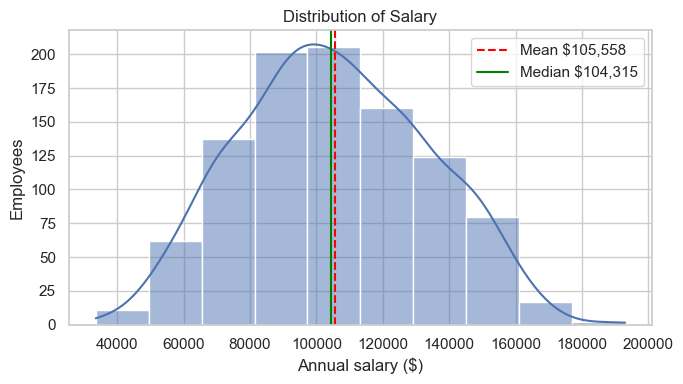

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_salarydata[TARGET], bins=10, kde=True, ax=ax)
ax.axvline(mean_s, color="red", ls="--", label=f"Mean ${mean_s:,.0f}")
ax.axvline(median_s, color="green", label=f"Median ${median_s:,.0f}")
ax.set(title="Distribution of Salary", xlabel="Annual salary ($)", ylabel="Employees")
ax.legend(); plt.tight_layout(); plt.savefig("images/salary_dist.png", dpi=130); plt.show()

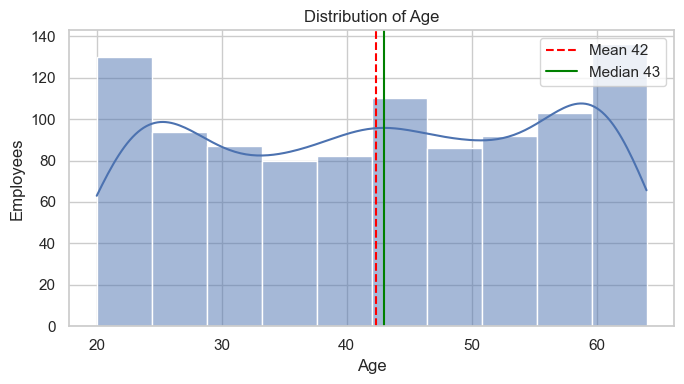

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df_salarydata['Age'], bins=10, kde=True, ax=ax)
ax.axvline(mean_age, color="red", ls="--", label=f"Mean {mean_age:,.0f}")
ax.axvline(median_age, color="green", label=f"Median {median_age:,.0f}")
ax.set(title="Distribution of Age", xlabel="Age", ylabel="Employees")
ax.legend(); plt.tight_layout(); plt.savefig("images/age_dist.png", dpi=130); plt.show()

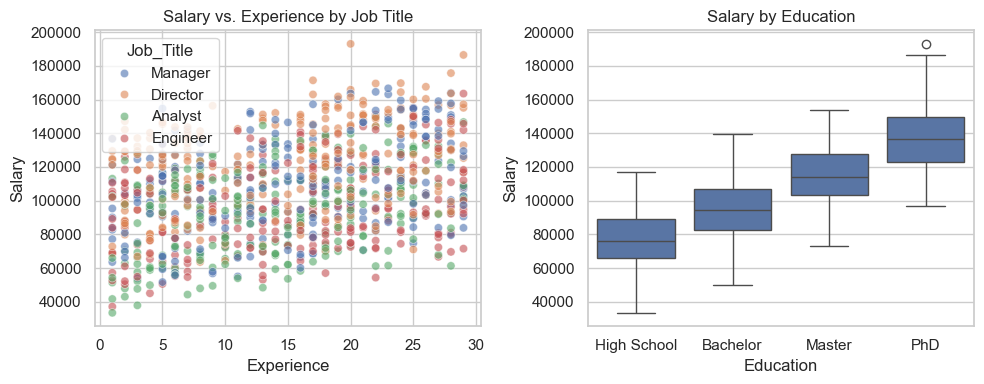

,count,mean,median
Job_Title,,,
Engineer,229,97266.0,94955.0
Analyst,255,93802.0,96311.0
Manager,241,108736.0,107464.0
Director,275,120581.0,121924.0


,count,mean,median
Education,,,
High School,255,76849.0,76321.0
Bachelor,253,94612.0,94566.0
Master,241,115477.0,113967.0
PhD,251,136235.0,136686.0


,count,mean,median
Location,,,
Rural,345,98677.0,97053.0
Suburban,345,107603.0,107267.0
Urban,310,110941.0,111289.0


,count,mean,median
Gender,,,
Female,484,104737.0,103702.0
Male,516,106329.0,105175.0


Age/Experience correlation: 0.044


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=df_salarydata, x="Experience", y=TARGET, hue="Job_Title", alpha=.6, ax=ax[0])
ax[0].set_title("Salary vs. Experience by Job Title")
order = df_salarydata.groupby("Education")[TARGET].median().sort_values().index
sns.boxplot(data=df_salarydata, x="Education", y=TARGET, order=order, ax=ax[1])
ax[1].set_title("Salary by Education")
plt.tight_layout(); plt.savefig("images/eda.png", dpi=130); plt.show()

# Mean and median salary by group
for col in ["Job_Title", "Education", "Location", "Gender"]:
    display(df_salarydata.groupby(col)[TARGET].agg(count="count", mean="mean", median="median").round(0).sort_values("median"))

print("Age/Experience correlation:", round(df_salarydata["Age"].corr(df_salarydata["Experience"]), 3))

Dataset can be converted to categorical variables and some cannot be not be considered as catgorical. Dummy variables can also be used in one hot encoding

## 5. Data Preparation and Feature Selection


In [11]:
X = df.drop(columns=TARGET)
y = df[TARGET]
num_cols = ["Age", "Experience"]
cat_cols = ["Gender", "Education", "Job_Title", "Location"]

# Split BEFORE fitting anything (prevents leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Preprocessing lives inside the pipeline, so it is learned from training data only
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
print(X_train.shape, X_test.shape)

(800, 6) (200, 6)


## 6. Baseline and Model Development


In [23]:
def evaluate(model, X_, y_):
    p = model.predict(X_)
    return mean_absolute_error(y_, p), np.sqrt(mean_squared_error(y_, p)), r2_score(y_, p)

rows = []
for strategy in ["mean", "median"]:
    m = DummyRegressor(strategy=strategy).fit(X_train, y_train)
    rows.append((f"Baseline ({strategy})", None, *evaluate(m, X_test, y_test)))

models = {
    "Linear Regression": LinearRegression(),
    ##"Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE),
    ##"Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # same folds for every model
pipes = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error").mean()
    pipe.fit(X_train, y_train)
    pipes[name] = pipe
    rows.append((name, cv_rmse, *evaluate(pipe, X_test, y_test)))

results = pd.DataFrame(rows, columns=["Model", "CV RMSE", "Test MAE", "Test RMSE", "Test R2"]).set_index("Model")
results.round(3)

,CV RMSE,Test MAE,Test RMSE,Test R2
Model,,,,
Baseline (mean),NaN,23077.010,28602.317,-0.002
Baseline (median),NaN,23123.556,28689.242,-0.008
Linear Regression,9971.441,8157.898,10295.449,0.870
Random Forest,10980.749,8968.559,10994.488,0.852


## 7. Model Evaluation and Selection
**MAE** is the average dollar error, **RMSE** penalizes large misses more, and **R²** is the share of salary variation explained (0 means no better than the mean).

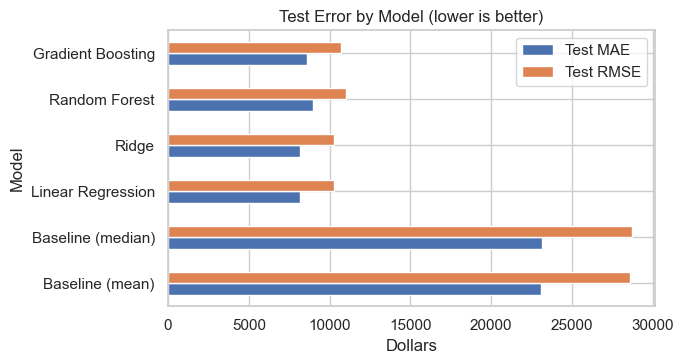

Best model by test RMSE: Ridge


In [13]:
fig, ax = plt.subplots(figsize=(7, 3.8))
results[["Test MAE", "Test RMSE"]].plot.barh(ax=ax)
ax.set(title="Test Error by Model (lower is better)", xlabel="Dollars")
plt.tight_layout(); plt.savefig("images/models.png", dpi=130); plt.show()

trained = results.drop(index=["Baseline (mean)", "Baseline (median)"])
best_name = trained["Test RMSE"].idxmin()
print("Best model by test RMSE:", best_name)

*Figure 3. All trained models beat both baselines by a wide margin.*

I selected **Ridge** because it had the lowest test RMSE ($13,070) and the highest R² (0.834), compared with $32,087 and -0.000 for the mean baseline. Differences among the top models were small, so a simpler linear model would also be a reasonable choice when explainability matters most.

## 8. Model Interpretation and Insights

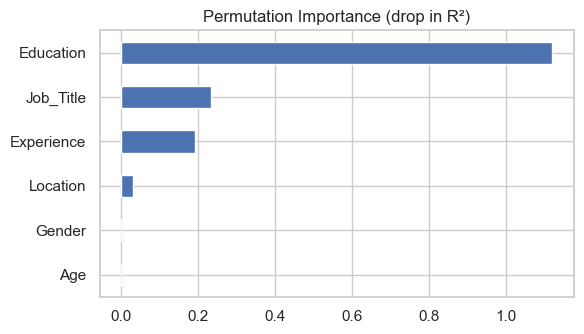

In [14]:
best = pipes[best_name]
pred = best.predict(X_test)

pi = permutation_importance(best, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="r2")
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(6, 3.5))
imp.plot.barh(ax=ax, title="Permutation Importance (drop in R²)")
plt.tight_layout(); plt.savefig("images/imp.png", dpi=130); plt.show()

*Figure 4. Experience and Job_Title matter most to predictions.*

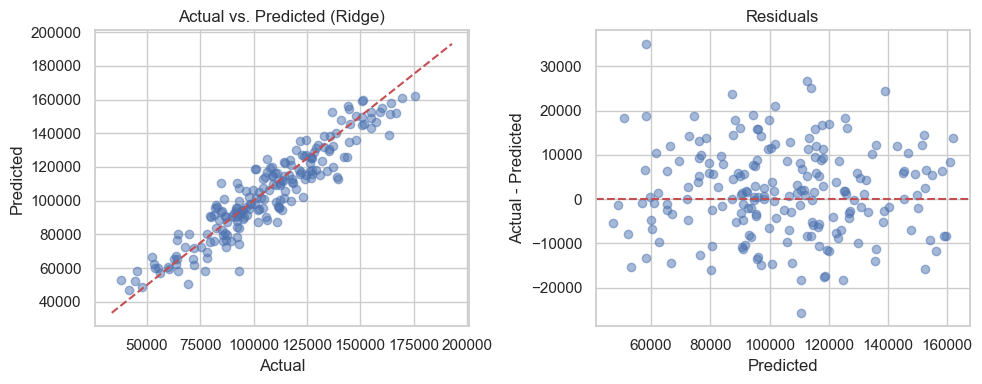

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(y_test, pred, alpha=.5)
lim = [y.min(), y.max()]; ax[0].plot(lim, lim, "r--")
ax[0].set(title=f"Actual vs. Predicted ({best_name})", xlabel="Actual", ylabel="Predicted")
ax[1].scatter(pred, y_test - pred, alpha=.5); ax[1].axhline(0, color="r", ls="--")
ax[1].set(title="Residuals", xlabel="Predicted", ylabel="Actual - Predicted")
plt.tight_layout(); plt.savefig("images/pred.png", dpi=130); plt.show()

*Figure 5. Predictions track actual salaries closely; errors grow for the highest salaries.*

In [16]:
# Predicted vs. actual mean/median salary by job title (test set)
out = X_test.copy(); out["Actual"] = y_test; out["Predicted"] = pred
by_job = out.groupby("Job_Title").agg(
    n=("Actual", "size"),
    actual_mean=("Actual", "mean"), predicted_mean=("Predicted", "mean"),
    actual_median=("Actual", "median"), predicted_median=("Predicted", "median"),
).round(0).sort_values("actual_median")
by_job

,n,actual_mean,predicted_mean,actual_median,predicted_median
Job_Title,,,,,
Engineer,56,98652.0,95397.0,94238.0,94265.0
Analyst,44,93618.0,93940.0,101644.0,98980.0
Manager,49,114630.0,111969.0,113746.0,106864.0
Director,51,118654.0,117377.0,114580.0,115318.0


Predicted group means and medians line up closely with actual values. The model shows association, not causation: it cannot say that more education *causes* higher pay.

## 9. Limitations, Ethics, and Reflection

In [17]:
# Gender check: mean actual, predicted, and error (actual - predicted)
chk = out.assign(Error=out["Actual"] - out["Predicted"])
chk.groupby("Gender")[["Actual", "Predicted", "Error"]].mean().round(0)

,Actual,Predicted,Error
Gender,,,
Female,102722.0,100949.0,1773.0
Male,110975.0,109105.0,1870.0


- **Synthetic data:** patterns here reflect how the data was generated, not a real labor market.
- **Gender check:** average prediction error was $1,956 to $3,549 across genders. Large gaps in a real dataset would signal that the model treats groups differently.
- **Errors:** under-predicting a salary could lead to a lowball offer; over-predicting could set unrealistic expectations.
- **Real-world use:** not ready. It should only inform, never replace, human judgment on pay.
- **Next steps:** real data with employer information, more features such as industry and skills, and a formal fairness audit.

## 10. Code and Transparency
Code: [GitHub repository](https://github.com/your-username/your-repo)

| Tool | Purpose | Verification |
|---|---|---|
| Claude | Drafted the template and example analysis code | I reviewed and modified the code myself and rewrote the explanations for my project objective |